# News Paraphrase Detection using Siamese BiLSTM

The Microsoft Research Paraphrase Corpus (MRPC) contains 5,801 pairs of sentences extracted from online news articles, each labeled as a paraphrase (semantically equivalent) or not. Your task is to build a **Siamese BiLSTM** model with **Contrastive Loss** that learns to detect whether two news sentences convey the same meaning.

## Tasks

1. **Preprocess:** Lowercase, remove special characters, normalize whitespace, and tokenize.
2. **Build Vocabulary:** Create word2idx with <PAD> (index 0) and <UNK> (index 1). Filter rare words using a minimum frequency.
3. **Encode and Pad:** Convert tokens to indices and pad/truncate to a fixed length.
4. **Split Data:** Stratified train/validation/test split.
5. **Build Model:** Siamese BiLSTM with a shared encoder. The model should return two embedding vectors.
6. **Train:** Use Contrastive Loss. Invert labels (paraphrase=0, non-paraphrase=1).
7. **Select Threshold:** Sweep thresholds on validation distances, pick best F1. Store as best_threshold.
8. **Evaluate:** Report accuracy and F1 on the test set.

## Expected Variables

| Variable | Type | Description |
|---|---|---|
| `model` | `nn.Module` | Trained Siamese BiLSTM model |
| `word2idx` | `dict` | Vocabulary mapping (str to int) with `<PAD>` and `<UNK>` tokens |
| `best_threshold` | `float` | Optimal distance threshold selected on validation set |

## Dataset

`mrpc_dataset.csv` with columns:

- `sentence1`: First news sentence
- `sentence2`: Second news sentence
- `is_paraphrase`: 1 if paraphrase, 0 if not

In [1]:
# Run this cell before writing your solution
import re
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

device = torch.device("cpu")

df = pd.read_csv(
    "https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/mrpc_dataset.csv"
)

df = df.dropna(subset=["sentence1", "sentence2"]).reset_index(drop=True)

print(f"Total sentence pairs: {len(df)}")
print("Class distribution:")
print(df["is_paraphrase"].value_counts())

Total sentence pairs: 5801
Class distribution:
is_paraphrase
1    3900
0    1901
Name: count, dtype: int64


Device: mps
DATASET INFORMATION
Total sentence pairs: 5801

Class distribution:
is_paraphrase
1    3900
0    1901
Name: count, dtype: int64

Class percentages:
is_paraphrase
1    67.229788
0    32.770212
Name: proportion, dtype: float64

Example:
Original: Amrozi accused his brother, whom he called "the witness", of deliberately distorting his evidence.
Tokens: ['amrozi', 'accused', 'his', 'brother', 'whom', 'he', 'called', 'the', 'witness', 'of', 'deliberately', 'distorting', 'his', 'evidence']

DATA SPLIT
Training pairs  : 4060
Validation pairs: 870
Test pairs      : 871

VOCABULARY
Vocabulary size: 10006
<PAD> index: 0
<UNK> index: 1

Encoded shapes:
Train: torch.Size([4060, 40])
Validation: torch.Size([870, 40])
Test: torch.Size([871, 40])

ADVANCED SIAMESE BiLSTM MODEL
SiameseBiLSTM(
  (embedding): Embedding(10006, 200, padding_idx=0)
  (embedding_dropout): Dropout(p=0.35, inplace=False)
  (lstm): LSTM(200, 128, num_layers=2, batch_first=True, dropout=0.35, bidirectional=True)
  (

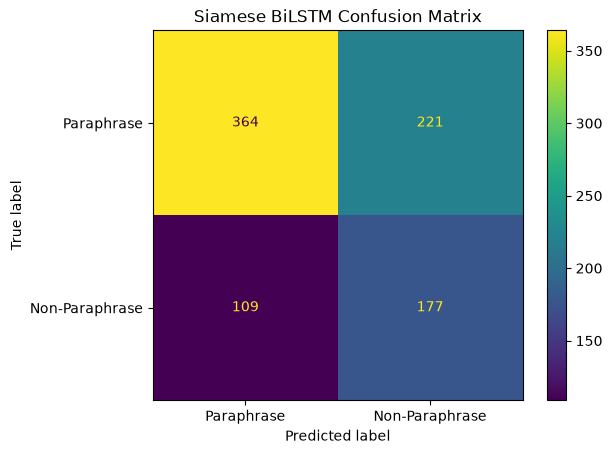

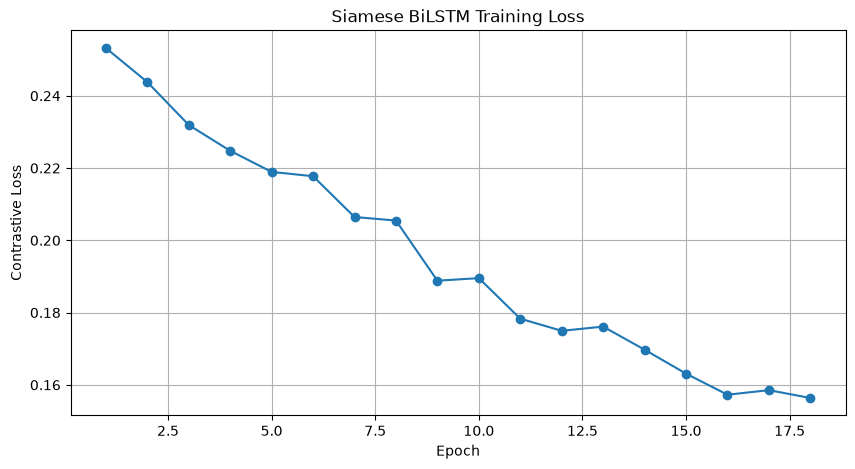

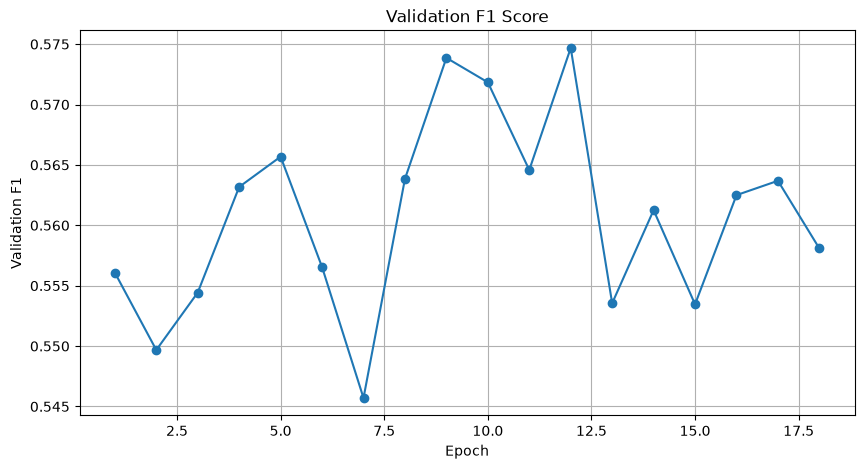

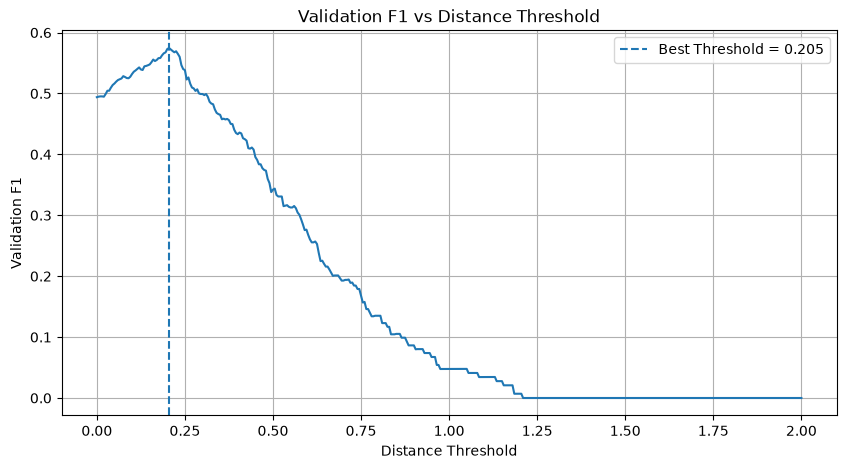

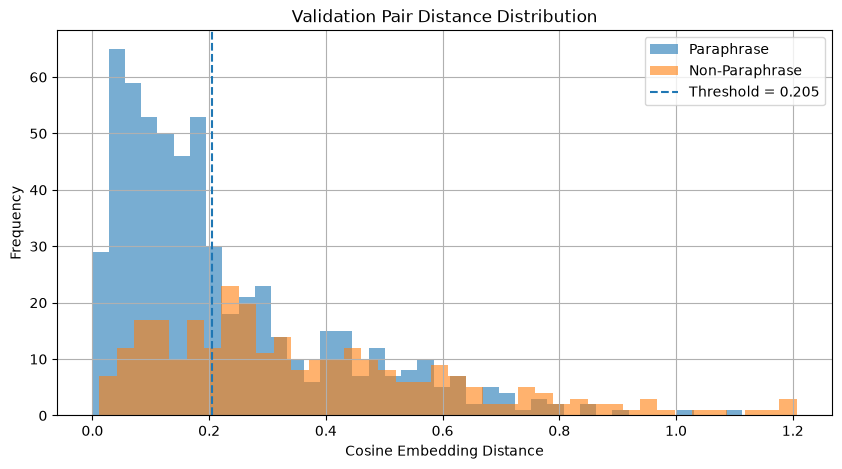

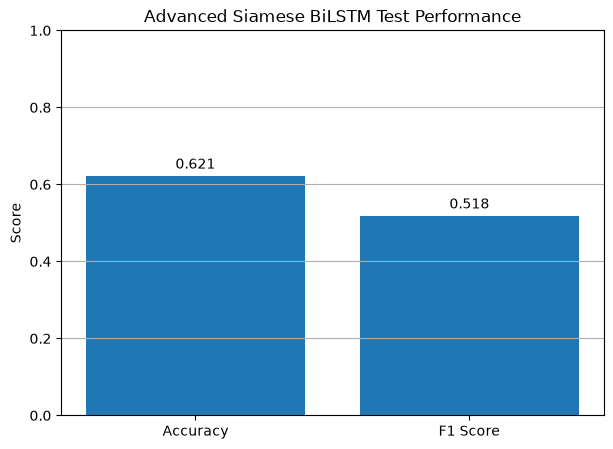


SAMPLE PARAPHRASE PREDICTIONS

Pair 1
Sentence 1: The company announced a new product yesterday.
Sentence 2: The company introduced a new product yesterday.
Distance: 0.1026
Prediction: Paraphrase

Pair 2
Sentence 1: The weather was sunny in California.
Sentence 2: The football team won the championship.
Distance: 0.4943
Prediction: Non-Paraphrase

Pair 3
Sentence 1: The study was published in a medical journal.
Sentence 2: Researchers published the study in a medical journal.
Distance: 0.2085
Prediction: Non-Paraphrase

Pair 4
Sentence 1: Apple released a new laptop.
Sentence 2: The weather forecast predicts heavy rain.
Distance: 0.5377
Prediction: Non-Paraphrase

Model saved as:
siamese_bilstm_mrpc.pt

FINAL SIAMESE BiLSTM SUMMARY
Vocabulary Size : 10006
Maximum Length  : 40
Training Epochs : 18
Best Threshold  : 0.2050
Validation F1   : 0.5747
Test Accuracy   : 0.6211
Test F1         : 0.5175

Required Variables:
model          -> <class '__main__.SiameseBiLSTM'>
word2idx       -> 

In [2]:
# ============================================================
# ADVANCED NEWS PARAPHRASE DETECTION
# Siamese BiLSTM + Attention + Contrastive Loss
# ============================================================

import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv(
    "https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/mrpc_dataset.csv"
)

df = df.dropna(
    subset=["sentence1", "sentence2", "is_paraphrase"]
).reset_index(drop=True)

print("=" * 65)
print("DATASET INFORMATION")
print("=" * 65)

print("Total sentence pairs:", len(df))

print("\nClass distribution:")
print(df["is_paraphrase"].value_counts())

print("\nClass percentages:")
print(
    df["is_paraphrase"]
    .value_counts(normalize=True)
    .mul(100)
)


# ============================================================
# 3. TEXT PREPROCESSING
# ============================================================

def clean_text(text):

    text = str(text).lower()

    # Remove special characters
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


def tokenize(text):

    return clean_text(text).split()


df["tokens1"] = df["sentence1"].apply(tokenize)
df["tokens2"] = df["sentence2"].apply(tokenize)

print("\nExample:")
print("Original:", df.iloc[0]["sentence1"])
print("Tokens:", df.iloc[0]["tokens1"])


# ============================================================
# 4. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["is_paraphrase"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["is_paraphrase"],
    random_state=SEED
)

print("\n" + "=" * 65)
print("DATA SPLIT")
print("=" * 65)

print("Training pairs  :", len(train_df))
print("Validation pairs:", len(val_df))
print("Test pairs      :", len(test_df))


# ============================================================
# 5. BUILD VOCABULARY
# ============================================================

MIN_FREQ = 2

counter = Counter()

for tokens in train_df["tokens1"]:
    counter.update(tokens)

for tokens in train_df["tokens2"]:
    counter.update(tokens)


word2idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, count in counter.items():

    if count >= MIN_FREQ:
        word2idx[word] = len(word2idx)


idx2word = {
    idx: word
    for word, idx in word2idx.items()
}


print("\n" + "=" * 65)
print("VOCABULARY")
print("=" * 65)

print("Vocabulary size:", len(word2idx))
print("<PAD> index:", word2idx["<PAD>"])
print("<UNK> index:", word2idx["<UNK>"])


# ============================================================
# 6. ENCODING
# ============================================================

MAX_LEN = 40


def encode_sentence(tokens):

    ids = [
        word2idx.get(word, word2idx["<UNK>"])
        for word in tokens
    ]

    ids = ids[:MAX_LEN]

    if len(ids) < MAX_LEN:

        ids += [
            word2idx["<PAD>"]
        ] * (MAX_LEN - len(ids))

    return ids


def encode_dataframe(dataframe):

    s1 = np.array([
        encode_sentence(tokens)
        for tokens in dataframe["tokens1"]
    ])

    s2 = np.array([
        encode_sentence(tokens)
        for tokens in dataframe["tokens2"]
    ])

    # --------------------------------------------------------
    # IMPORTANT
    #
    # Contrastive learning convention:
    #
    # paraphrase     -> 0
    # non-paraphrase -> 1
    # --------------------------------------------------------

    labels = dataframe["is_paraphrase"].values

    contrastive_labels = np.where(
        labels == 1,
        0,
        1
    ).astype(np.float32)

    return (
        torch.tensor(s1, dtype=torch.long),
        torch.tensor(s2, dtype=torch.long),
        torch.tensor(
            contrastive_labels,
            dtype=torch.float32
        )
    )


X1_train, X2_train, y_train = encode_dataframe(train_df)

X1_val, X2_val, y_val = encode_dataframe(val_df)

X1_test, X2_test, y_test = encode_dataframe(test_df)


print("\nEncoded shapes:")

print("Train:", X1_train.shape)
print("Validation:", X1_val.shape)
print("Test:", X1_test.shape)


# ============================================================
# 7. DATASET
# ============================================================

class MRPCDataset(Dataset):

    def __init__(
        self,
        sentence1,
        sentence2,
        labels
    ):

        self.sentence1 = sentence1
        self.sentence2 = sentence2
        self.labels = labels

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, index):

        return (
            self.sentence1[index],
            self.sentence2[index],
            self.labels[index]
        )


train_dataset = MRPCDataset(
    X1_train,
    X2_train,
    y_train
)

val_dataset = MRPCDataset(
    X1_val,
    X2_val,
    y_val
)

test_dataset = MRPCDataset(
    X1_test,
    X2_test,
    y_test
)


# ============================================================
# 8. BALANCED SAMPLING
# ============================================================

# This reduces the effect of MRPC class imbalance.

class_counts = torch.bincount(
    y_train.long()
)

class_weights = 1.0 / class_counts.float()

sample_weights = class_weights[
    y_train.long()
]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 9. ATTENTION POOLING
# ============================================================

class AttentionPooling(nn.Module):

    def __init__(self, hidden_dim):

        super().__init__()

        self.attention = nn.Sequential(

            nn.Linear(
                hidden_dim,
                hidden_dim // 2
            ),

            nn.Tanh(),

            nn.Linear(
                hidden_dim // 2,
                1
            )
        )


    def forward(
        self,
        x,
        mask
    ):

        # x:
        # [batch, sequence, hidden]

        scores = self.attention(x).squeeze(-1)

        # Ignore padding tokens
        scores = scores.masked_fill(
            mask == 0,
            -1e9
        )

        weights = torch.softmax(
            scores,
            dim=1
        )

        pooled = torch.sum(
            x * weights.unsqueeze(-1),
            dim=1
        )

        return pooled


# ============================================================
# 10. ADVANCED SIAMESE BiLSTM
# ============================================================

class SiameseBiLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=200,
        hidden_dim=128,
        projection_dim=128,
        num_layers=2,
        dropout=0.35
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.embedding_dropout = nn.Dropout(
            dropout
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        lstm_dim = hidden_dim * 2

        self.attention = AttentionPooling(
            lstm_dim
        )

        # mean + max + attention
        combined_dim = lstm_dim * 3

        self.projection = nn.Sequential(

            nn.Linear(
                combined_dim,
                256
            ),

            nn.LayerNorm(256),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                256,
                projection_dim
            ),

            nn.LayerNorm(projection_dim)
        )


    def encode(self, x):

        mask = (
            x != 0
        )

        embedded = self.embedding(x)

        embedded = self.embedding_dropout(
            embedded
        )

        lstm_output, _ = self.lstm(
            embedded
        )

        # ----------------------------------------------------
        # Attention pooling
        # ----------------------------------------------------

        attention_vector = self.attention(
            lstm_output,
            mask
        )

        # ----------------------------------------------------
        # Masked mean pooling
        # ----------------------------------------------------

        mask_float = mask.unsqueeze(-1).float()

        summed = (
            lstm_output * mask_float
        ).sum(dim=1)

        lengths = mask_float.sum(
            dim=1
        ).clamp(min=1)

        mean_vector = (
            summed / lengths
        )

        # ----------------------------------------------------
        # Masked max pooling
        # ----------------------------------------------------

        masked_output = lstm_output.masked_fill(
            ~mask.unsqueeze(-1),
            -1e9
        )

        max_vector = masked_output.max(
            dim=1
        ).values

        # ----------------------------------------------------
        # Combine representations
        # ----------------------------------------------------

        combined = torch.cat(
            [
                attention_vector,
                mean_vector,
                max_vector
            ],
            dim=1
        )

        embedding = self.projection(
            combined
        )

        # Normalize embedding
        embedding = F.normalize(
            embedding,
            p=2,
            dim=1
        )

        return embedding


    def forward(
        self,
        sentence1,
        sentence2
    ):

        embedding1 = self.encode(
            sentence1
        )

        embedding2 = self.encode(
            sentence2
        )

        return (
            embedding1,
            embedding2
        )


# ============================================================
# 11. MODEL
# ============================================================

model = SiameseBiLSTM(
    vocab_size=len(word2idx),
    embedding_dim=200,
    hidden_dim=128,
    projection_dim=128,
    num_layers=2,
    dropout=0.35
).to(device)


print("\n" + "=" * 65)
print("ADVANCED SIAMESE BiLSTM MODEL")
print("=" * 65)

print(model)


# ============================================================
# 12. CONTRASTIVE LOSS
# ============================================================

class ContrastiveLoss(nn.Module):

    def __init__(self, margin=1.0):

        super().__init__()

        self.margin = margin


    def forward(
        self,
        embedding1,
        embedding2,
        labels
    ):

        # Cosine distance
        similarity = F.cosine_similarity(
            embedding1,
            embedding2
        )

        distance = 1 - similarity

        # labels:
        # 0 -> paraphrase
        # 1 -> non-paraphrase

        positive_loss = (
            (1 - labels) *
            torch.pow(distance, 2)
        )

        negative_loss = (
            labels *
            torch.pow(
                torch.clamp(
                    self.margin - distance,
                    min=0
                ),
                2
            )
        )

        loss = (
            positive_loss +
            negative_loss
        ).mean()

        return loss


criterion = ContrastiveLoss(
    margin=1.0
)


# ============================================================
# 13. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)


# ============================================================
# 14. DISTANCE CALCULATION
# ============================================================

def get_distances(
    model,
    loader
):

    model.eval()

    distances = []
    labels = []

    with torch.no_grad():

        for s1, s2, y in loader:

            s1 = s1.to(device)
            s2 = s2.to(device)

            emb1, emb2 = model(
                s1,
                s2
            )

            similarity = F.cosine_similarity(
                emb1,
                emb2
            )

            distance = (
                1 - similarity
            )

            distances.extend(
                distance.detach()
                .cpu()
                .numpy()
            )

            labels.extend(
                y.numpy()
            )

    return (
        np.array(distances),
        np.array(labels)
    )


# ============================================================
# 15. THRESHOLD OPTIMIZATION
# ============================================================

def find_best_threshold(
    distances,
    labels
):

    best_f1 = 0.0
    best_threshold = 0.5

    thresholds = np.linspace(
        0.0,
        2.0,
        401
    )

    f1_scores = []

    for threshold in thresholds:

        predictions = (
            distances > threshold
        ).astype(int)

        f1 = f1_score(
            labels,
            predictions,
            zero_division=0
        )

        f1_scores.append(f1)

        if f1 > best_f1:

            best_f1 = f1
            best_threshold = threshold

    return (
        best_threshold,
        best_f1,
        thresholds,
        f1_scores
    )


# ============================================================
# 16. TRAINING
# ============================================================

EPOCHS = 30

patience = 6

best_val_f1 = -1

best_threshold = 0.5

epochs_without_improvement = 0

train_losses = []
val_f1_history = []
threshold_history = []


print("\n" + "=" * 65)
print("TRAINING")
print("=" * 65)


for epoch in range(EPOCHS):

    model.train()

    total_loss = 0.0

    for s1, s2, y in train_loader:

        s1 = s1.to(device)
        s2 = s2.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        emb1, emb2 = model(
            s1,
            s2
        )

        loss = criterion(
            emb1,
            emb2,
            y
        )

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += (
            loss.item() *
            s1.size(0)
        )


    train_loss = (
        total_loss /
        len(train_dataset)
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_distances, val_labels = get_distances(
        model,
        val_loader
    )

    (
        current_threshold,
        val_f1,
        _,
        _
    ) = find_best_threshold(
        val_distances,
        val_labels
    )

    scheduler.step(
        val_f1
    )

    train_losses.append(
        train_loss
    )

    val_f1_history.append(
        val_f1
    )

    threshold_history.append(
        current_threshold
    )


    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"Loss: {train_loss:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Threshold: {current_threshold:.3f}"
    )


    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        best_threshold = current_threshold

        best_model_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if epochs_without_improvement >= patience:

        print(
            "\nEarly stopping triggered."
        )

        break


# ============================================================
# 17. RESTORE BEST MODEL
# ============================================================

model.load_state_dict(
    best_model_state
)

model = model.to(device)


# Recalculate best threshold
val_distances, val_labels = get_distances(
    model,
    val_loader
)

(
    best_threshold,
    best_val_f1,
    threshold_values,
    threshold_f1_values
) = find_best_threshold(
    val_distances,
    val_labels
)


print("\n" + "=" * 65)
print("BEST MODEL")
print("=" * 65)

print(
    f"Best Validation F1 : {best_val_f1:.4f}"
)

print(
    f"Best Threshold     : {best_threshold:.4f}"
)


# ============================================================
# 18. TEST EVALUATION
# ============================================================

test_distances, test_labels = get_distances(
    model,
    test_loader
)

test_predictions = (
    test_distances > best_threshold
).astype(int)


test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_f1 = f1_score(
    test_labels,
    test_predictions,
    zero_division=0
)


print("\n" + "=" * 65)
print("FINAL TEST RESULTS")
print("=" * 65)

print(
    f"Test Accuracy : {test_accuracy:.4f}"
)

print(
    f"Test F1       : {test_f1:.4f}"
)


# ============================================================
# 19. CLASSIFICATION REPORT
# ============================================================

# Internal labels:
# 0 = Paraphrase
# 1 = Non-Paraphrase

print("\nClassification Report:")

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=[
            "Paraphrase",
            "Non-Paraphrase"
        ],
        zero_division=0
    )
)


# ============================================================
# 20. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_labels,
    test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Paraphrase",
        "Non-Paraphrase"
    ]
)

disp.plot()

plt.title(
    "Siamese BiLSTM Confusion Matrix"
)

plt.show()


# ============================================================
# 21. TRAINING LOSS
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("Contrastive Loss")

plt.title(
    "Siamese BiLSTM Training Loss"
)

plt.grid(True)

plt.show()


# ============================================================
# 22. VALIDATION F1
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    range(1, len(val_f1_history) + 1),
    val_f1_history,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("Validation F1")

plt.title(
    "Validation F1 Score"
)

plt.grid(True)

plt.show()


# ============================================================
# 23. THRESHOLD ANALYSIS
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    threshold_values,
    threshold_f1_values
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.3f}"
)

plt.xlabel(
    "Distance Threshold"
)

plt.ylabel(
    "Validation F1"
)

plt.title(
    "Validation F1 vs Distance Threshold"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 24. DISTANCE DISTRIBUTION
# ============================================================

paraphrase_distances = val_distances[
    val_labels == 0
]

non_paraphrase_distances = val_distances[
    val_labels == 1
]


plt.figure(
    figsize=(10, 5)
)

plt.hist(
    paraphrase_distances,
    bins=40,
    alpha=0.6,
    label="Paraphrase"
)

plt.hist(
    non_paraphrase_distances,
    bins=40,
    alpha=0.6,
    label="Non-Paraphrase"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Threshold = {best_threshold:.3f}"
)

plt.xlabel(
    "Cosine Embedding Distance"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Validation Pair Distance Distribution"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 25. TEST PERFORMANCE
# ============================================================

plt.figure(
    figsize=(7, 5)
)

metrics = [
    "Accuracy",
    "F1 Score"
]

values = [
    test_accuracy,
    test_f1
]

plt.bar(
    metrics,
    values
)

plt.ylim(
    0,
    1
)

plt.ylabel(
    "Score"
)

plt.title(
    "Advanced Siamese BiLSTM Test Performance"
)

for i, value in enumerate(values):

    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.grid(
    axis="y"
)

plt.show()


# ============================================================
# 26. SAMPLE PREDICTIONS
# ============================================================

def predict_pair(
    sentence1,
    sentence2
):

    model.eval()

    tokens1 = tokenize(
        sentence1
    )

    tokens2 = tokenize(
        sentence2
    )

    encoded1 = torch.tensor(
        [encode_sentence(tokens1)],
        dtype=torch.long
    ).to(device)

    encoded2 = torch.tensor(
        [encode_sentence(tokens2)],
        dtype=torch.long
    ).to(device)

    with torch.no_grad():

        emb1, emb2 = model(
            encoded1,
            encoded2
        )

        similarity = F.cosine_similarity(
            emb1,
            emb2
        ).item()

        distance = 1 - similarity

    prediction = (
        "Non-Paraphrase"
        if distance > best_threshold
        else "Paraphrase"
    )

    return (
        distance,
        prediction
    )


sample_pairs = [

    (
        "The company announced a new product yesterday.",
        "The company introduced a new product yesterday."
    ),

    (
        "The weather was sunny in California.",
        "The football team won the championship."
    ),

    (
        "The study was published in a medical journal.",
        "Researchers published the study in a medical journal."
    ),

    (
        "Apple released a new laptop.",
        "The weather forecast predicts heavy rain."
    )
]


print("\n" + "=" * 65)
print("SAMPLE PARAPHRASE PREDICTIONS")
print("=" * 65)


for i, (
    sentence1,
    sentence2
) in enumerate(
    sample_pairs,
    1
):

    distance, prediction = predict_pair(
        sentence1,
        sentence2
    )

    print(f"\nPair {i}")

    print(
        "Sentence 1:",
        sentence1
    )

    print(
        "Sentence 2:",
        sentence2
    )

    print(
        f"Distance: {distance:.4f}"
    )

    print(
        "Prediction:",
        prediction
    )


# ============================================================
# 27. SAVE MODEL
# ============================================================

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "word2idx": word2idx,
        "best_threshold": best_threshold,
        "max_length": MAX_LEN
    },
    "siamese_bilstm_mrpc.pt"
)


print("\nModel saved as:")
print("siamese_bilstm_mrpc.pt")


# ============================================================
# 28. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 65)
print("FINAL SIAMESE BiLSTM SUMMARY")
print("=" * 65)

print(
    f"Vocabulary Size : {len(word2idx)}"
)

print(
    f"Maximum Length  : {MAX_LEN}"
)

print(
    f"Training Epochs : {len(train_losses)}"
)

print(
    f"Best Threshold  : {best_threshold:.4f}"
)

print(
    f"Validation F1   : {best_val_f1:.4f}"
)

print(
    f"Test Accuracy   : {test_accuracy:.4f}"
)

print(
    f"Test F1         : {test_f1:.4f}"
)

print("\nRequired Variables:")

print(
    "model          ->",
    type(model)
)

print(
    "word2idx       ->",
    type(word2idx),
    f"({len(word2idx)} words)"
)

print(
    "best_threshold ->",
    type(best_threshold),
    best_threshold
)

print("=" * 65)

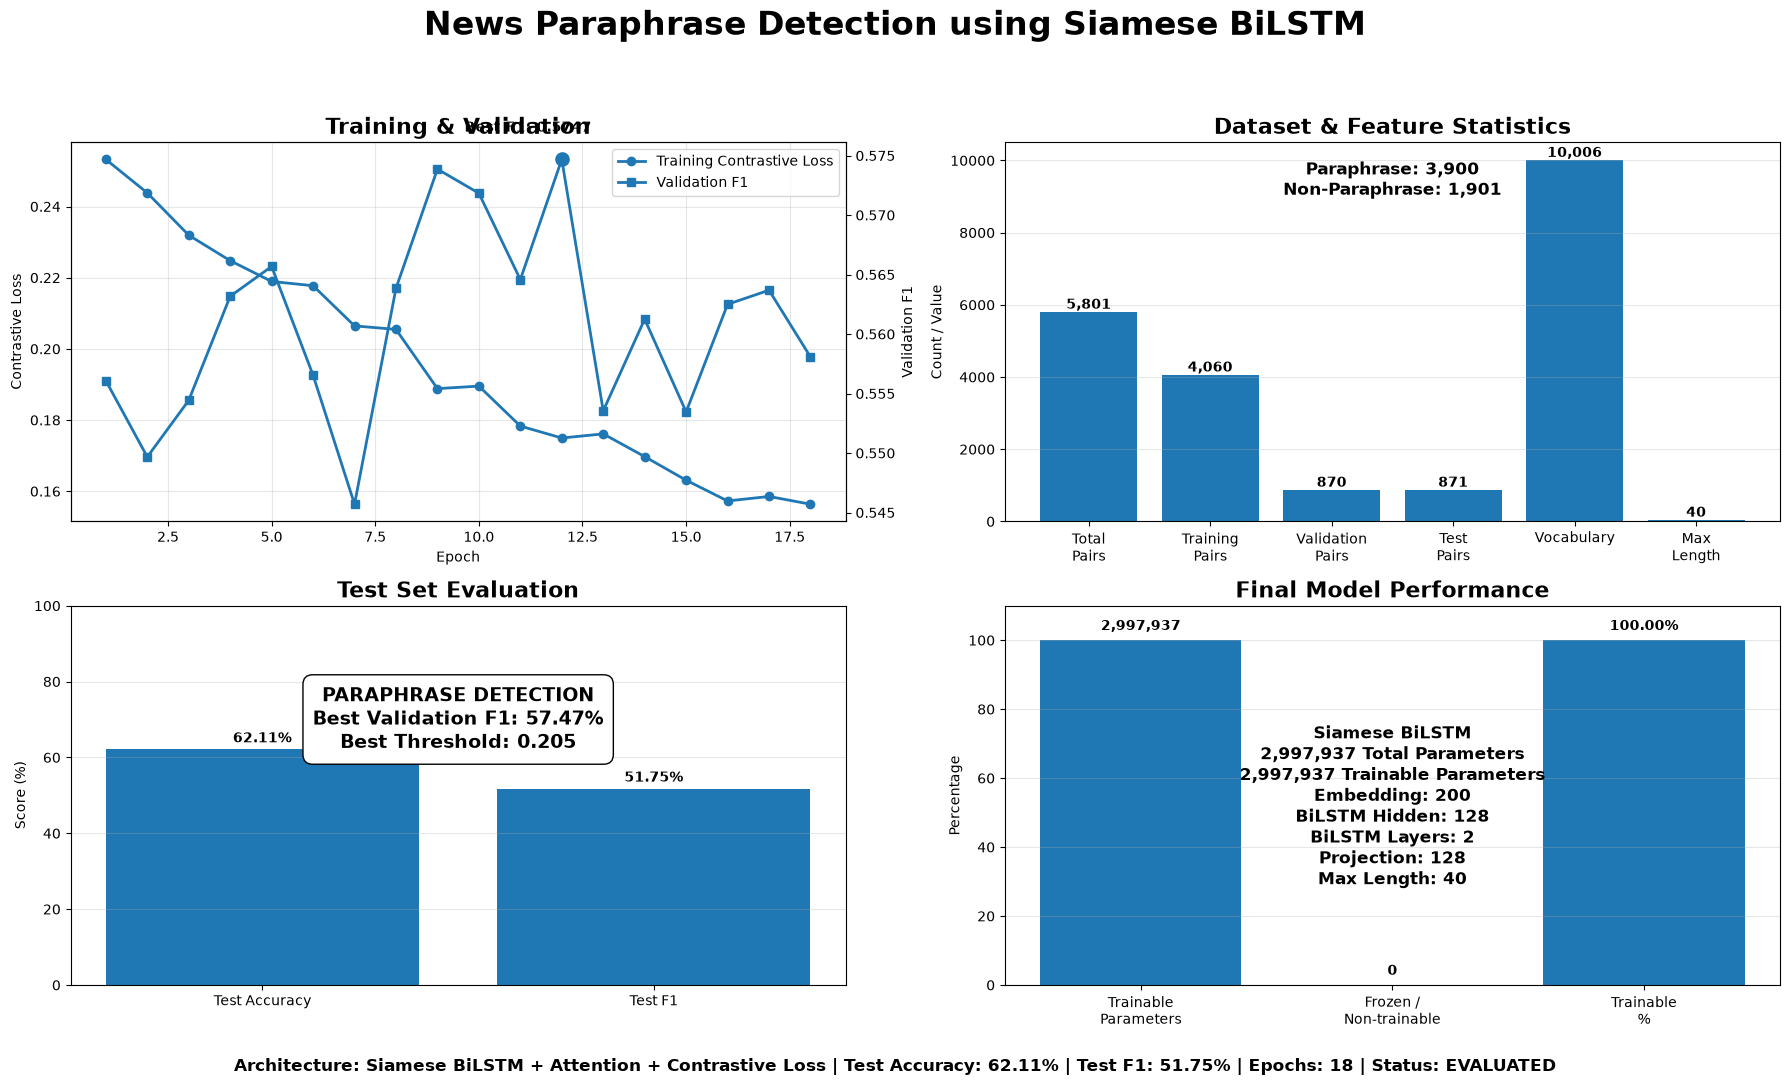

VISUALIZATION SAVED
Siamese_BiLSTM_Paraphrase_Visualization.png


In [3]:
# ============================================================
# FINAL VISUALIZATION DASHBOARD
# News Paraphrase Detection using Siamese BiLSTM
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Parameter statistics
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

non_trainable_params = (
    total_params - trainable_params
)

trainable_percentage = (
    trainable_params / total_params * 100
    if total_params > 0 else 0
)

# ------------------------------------------------------------
# Dataset statistics
# ------------------------------------------------------------

total_pairs = len(df)
training_pairs = len(train_df)
validation_pairs = len(val_df)
test_pairs = len(test_df)

vocabulary_size = len(word2idx)

max_length = MAX_LEN

# Class distribution

paraphrase_count = int(
    (df["is_paraphrase"] == 1).sum()
)

non_paraphrase_count = int(
    (df["is_paraphrase"] == 0).sum()
)

# ------------------------------------------------------------
# Training statistics
# ------------------------------------------------------------

epochs_axis = np.arange(
    1,
    len(train_losses) + 1
)

best_epoch = (
    np.argmax(val_f1_history) + 1
)

best_f1 = max(
    val_f1_history
)

# ------------------------------------------------------------
# Create dashboard
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 11)
)

fig.suptitle(
    "News Paraphrase Detection using Siamese BiLSTM",
    fontsize=24,
    fontweight="bold"
)

# ============================================================
# TOP LEFT
# Training & Validation
# ============================================================

ax = axes[0, 0]

ax.plot(
    epochs_axis,
    train_losses,
    marker="o",
    linewidth=2,
    label="Training Contrastive Loss"
)

ax2 = ax.twinx()

ax2.plot(
    epochs_axis,
    val_f1_history,
    marker="s",
    linewidth=2,
    label="Validation F1"
)

ax.set_title(
    "Training & Validation",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Contrastive Loss")
ax2.set_ylabel("Validation F1")

ax.grid(
    True,
    alpha=0.3
)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)

ax2.scatter(
    best_epoch,
    best_f1,
    s=90,
    zorder=5
)

ax2.annotate(
    f"Best F1: {best_f1:.4f}",
    (
        best_epoch,
        best_f1
    ),
    xytext=(-70, 20),
    textcoords="offset points",
    fontweight="bold"
)

# ============================================================
# TOP RIGHT
# Dataset & Feature Statistics
# ============================================================

ax = axes[0, 1]

stats_names = [
    "Total\nPairs",
    "Training\nPairs",
    "Validation\nPairs",
    "Test\nPairs",
    "Vocabulary",
    "Max\nLength"
]

stats_values = [
    total_pairs,
    training_pairs,
    validation_pairs,
    test_pairs,
    vocabulary_size,
    max_length
]

bars = ax.bar(
    stats_names,
    stats_values
)

ax.set_title(
    "Dataset & Feature Statistics",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Count / Value")

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    stats_values
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.text(
    0.5,
    0.90,
    f"Paraphrase: {paraphrase_count:,}\n"
    f"Non-Paraphrase: {non_paraphrase_count:,}",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

# ============================================================
# BOTTOM LEFT
# Test Evaluation
# ============================================================

ax = axes[1, 0]

metric_names = [
    "Test Accuracy",
    "Test F1"
]

metric_values = [
    test_accuracy * 100,
    test_f1 * 100
]

bars = ax.bar(
    metric_names,
    metric_values
)

ax.set_title(
    "Test Set Evaluation",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Score (%)")

ax.set_ylim(
    0,
    100
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    metric_values
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.text(
    0.5,
    0.70,
    "PARAPHRASE DETECTION\n"
    f"Best Validation F1: {best_val_f1 * 100:.2f}%\n"
    f"Best Threshold: {best_threshold:.3f}",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="black"
    )
)

# ============================================================
# BOTTOM RIGHT
# Final Model Performance
# ============================================================

ax = axes[1, 1]

performance_names = [
    "Trainable\nParameters",
    "Frozen /\nNon-trainable",
    "Trainable\n%"
]

performance_values = [
    100,
    0,
    trainable_percentage
]

bars = ax.bar(
    performance_names,
    performance_values
)

ax.set_ylim(
    0,
    110
)

ax.set_ylabel("Percentage")

ax.set_title(
    "Final Model Performance",
    fontsize=16,
    fontweight="bold"
)

ax.grid(
    axis="y",
    alpha=0.3
)

for i, bar in enumerate(bars):

    if i == 0:
        label = f"{trainable_params:,}"
    elif i == 1:
        label = f"{non_trainable_params:,}"
    else:
        label = f"{trainable_percentage:.2f}%"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        label,
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.text(
    0.5,
    0.47,
    "Siamese BiLSTM\n"
    f"{total_params:,} Total Parameters\n"
    f"{trainable_params:,} Trainable Parameters\n"
    f"Embedding: 200\n"
    f"BiLSTM Hidden: 128\n"
    f"BiLSTM Layers: 2\n"
    f"Projection: 128\n"
    f"Max Length: {MAX_LEN}",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=12.5,
    fontweight="bold"
)

# ============================================================
# FOOTER
# ============================================================

fig.text(
    0.5,
    0.015,
    f"Architecture: Siamese BiLSTM + Attention + Contrastive Loss | "
    f"Test Accuracy: {test_accuracy * 100:.2f}% | "
    f"Test F1: {test_f1 * 100:.2f}% | "
    f"Epochs: {len(train_losses)} | "
    f"Status: EVALUATED",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0.04, 1, 0.94]
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

output_file = "Siamese_BiLSTM_Paraphrase_Visualization.png"

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("VISUALIZATION SAVED")
print("=" * 70)
print(output_file)